In [22]:
%load_ext autoreload
%autoreload 2

import h5py
import torch
import numpy as np
from pathlib import Path

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
def hdf5_to_dict(hdf5_path):
    with h5py.File(hdf5_path, 'r') as hdf5_file:
        data_dict = {
            'qpos': torch.tensor(hdf5_file['observations']['qpos'][:])
        }
        for key in hdf5_file['observations']['images'].keys():
            data_dict[key] = torch.tensor(hdf5_file['observations']['images'][key][:])
    return data_dict

data = hdf5_to_dict(Path('processed_data/sim-lift_bottle/v3-50/episode_0.hdf5'))

In [3]:
print(data['qpos'].shape)
print(data['cam_high'].shape)
print(data['tac_left'].shape)
print(data['tac_right'].shape)

torch.Size([270, 8])
torch.Size([270, 270, 480, 3])
torch.Size([270, 240, 320, 3])
torch.Size([270, 240, 320, 3])


In [38]:
def visualize_frame(a, b, c, a_normed=False):
    from PIL import Image
    import numpy as np
    
    def trans(x, normed=False):
        if isinstance(x, torch.Tensor):
            if x.size(-1) != 3:
                x = x.cpu().permute(1, 2, 0).numpy()
            else:
                x = x.cpu().numpy()
        if normed:
            x = np.clip(x * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406]), 0, 1)
        if np.max(x) <= 1.0:
            x = x * 255
        return x.astype('uint8')

    a = trans(a, normed=a_normed)
    b = trans(b)
    c = trans(c)
    
    a = Image.fromarray(a).convert('RGB').resize((256, 256))
    obs = Image.new('RGB', (a.width, a.height))
    b = Image.fromarray(b).convert('RGB')
    b = b.resize((64, 64))
    c = Image.fromarray(c).convert('RGB')
    c = c.resize((64, 64))

    obs.paste(a, (0, 0))
    obs.paste(b, (0, 0))
    obs.paste(c, (256-64, 0))
    
    import matplotlib.pyplot as plt
    plt.imshow(obs)
    plt.axis('off')
    plt.show()

def visualize_qpos(qpos):
    l = qpos.tolist()
    print(f"qpos: {[round(f, 4) for f in l]}")

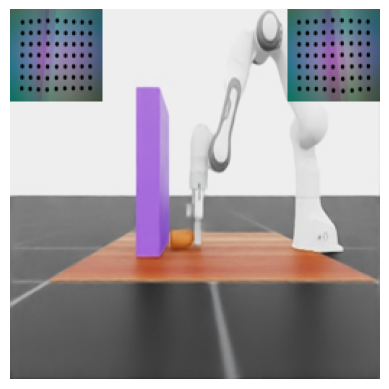

In [18]:
f = 40
visualize_frame(data['cam_high'][f], data['tac_left'][f], data['tac_right'][f])

In [109]:
from deploy_policy import Policy

%set_env TRAIN_CONFIG=train_config_vision
policy = Policy({
    'task_name': 'lift_bottle',
    'task_config': 'v3',
    'ckpt_setting': '50',
})

env: TRAIN_CONFIG=train_config_vision
Using camera type 'head' for task 'lift_bottle'
build_ACT_model_and_optimizer Namespace(lr=1e-05, lr_backbone=1e-05, batch_size=64, weight_decay=0.0001, epochs=300, lr_drop=200, clip_max_norm=0.1, dilation=False, pre_norm=False, masks=False, eval=False, onscreen_render=False, state_dim=8, kl_weight=10.0, chunk_size=50, hidden_dim=512, dim_feedforward=3200, temporal_agg=False, device='cuda:0', ckpt_dir='/mnt/data/tianxing/TacArena/policy/ACT_Modified/act_ckpt/act-lift_bottle/v3-50/train_config_vision', policy_class='ACT', num_epochs=1, save_freq=1000, position_embedding='sine', lr_vision_backbone=1e-05, backbone='resnet18', nheads=8, enc_layers=4, dec_layers=7, dropout=0.1, camera_names=['cam_high'], tactile_names=[], lr_tactile_backbone=0.0, tactile_masks=False, tactile_backbone='resnet18', tactile_ckpt='/mnt/data/tianxing/TacArena/encoder/checkpoints/resnet18/20251128-125750/best.pth', tactile_dilation=False, task_name='sim-lift_bottle-v3-50', tas

In [99]:
f = 50
observation = {
    'observation': {
        'head': {
            'rgb': data['cam_high'][f],
        }
    },
    'tactile': {
        'left_gsmini': {'rgb_marker': data['tac_left'][f]},
        'right_gsmini': {'rgb_marker': data['tac_right'][f]}
    },
    'embodiment': {'joint': data['qpos'][f]}
}
obs = policy.encode_obs(observation)

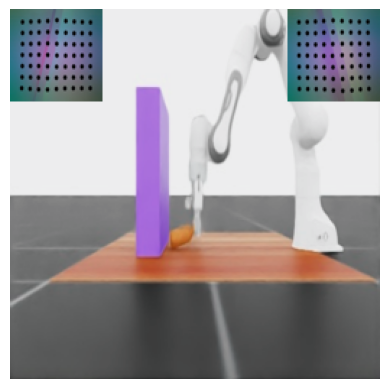

qpos: [0.0457, 0.4276, -0.0058, -2.2574, 0.0001, 2.7261, 0.7714, 0.0087]


In [100]:
visualize_frame(obs['cam_high'], obs['tac_left'], obs['tac_right'], a_normed=True)
visualize_qpos(obs['qpos'])

In [101]:
# policy.model.reset()
for _ in range(50):
    action = policy.model.get_action(obs)
    print(f'{policy.model.t:3d} ', end='')
    visualize_qpos(action.reshape(-1))

 51 qpos: [0.0538, 0.4968, -0.024, -2.2599, 0.0293, 2.7872, 0.8538, 0.0185]
 52 qpos: [0.0541, 0.4978, -0.0241, -2.2597, 0.0297, 2.787, 0.8541, 0.0171]
 53 qpos: [0.0534, 0.4985, -0.0242, -2.2599, 0.0297, 2.7868, 0.8532, 0.0155]
 54 qpos: [0.0532, 0.4989, -0.0241, -2.2594, 0.0297, 2.7862, 0.8536, 0.0138]
 55 qpos: [0.0517, 0.4993, -0.0239, -2.2595, 0.0296, 2.7851, 0.8525, 0.0126]
 56 qpos: [0.0518, 0.4989, -0.0237, -2.259, 0.0297, 2.7846, 0.8532, 0.0121]
 57 qpos: [0.0517, 0.4992, -0.0237, -2.2593, 0.0295, 2.7853, 0.8527, 0.0118]
 58 qpos: [0.0514, 0.4998, -0.0235, -2.2593, 0.0298, 2.7854, 0.8525, 0.0112]
 59 qpos: [0.0517, 0.4986, -0.0236, -2.2589, 0.0296, 2.7846, 0.8523, 0.011]
 60 qpos: [0.051, 0.4999, -0.0231, -2.2591, 0.0299, 2.7846, 0.8521, 0.0105]
 61 qpos: [0.0508, 0.4998, -0.0232, -2.2591, 0.03, 2.7854, 0.8525, 0.0103]
 62 qpos: [0.0507, 0.4996, -0.0232, -2.2594, 0.0299, 2.7853, 0.8517, 0.0099]
 63 qpos: [0.0498, 0.4996, -0.0229, -2.2592, 0.03, 2.7846, 0.8521, 0.0094]
 64 qpos